# Car Prises Analysis Project
## Objective
Analyze vehicle sales data to understand pricing trends, brands performance, and key factors influencing car prices.


In [7]:
import pandas as pd

In [4]:
# upload the car_prices?csv file to the Colab worksplase
from google.colab import files
uploaded = files.upload()

Saving car_prices.csv to car_prices.csv


In [8]:
df= pd.read_csv("car_prices.csv")

In [9]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
df.shape

(558837, 16)

In [ ]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [ ]:
# checking gaps in more detail
df.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


In [ ]:
#doing some stats on the price
df["sellingprice"].describe()

,sellingprice
count,558825.000000
mean,13611.358810
std,9749.501628
min,1.000000
25%,6900.000000
50%,12100.000000
75%,18200.000000
max,230000.000000


In [ ]:
#finding the frequency of stamps
df["make"].value_counts().head(10)

,count
make,
Ford,93554
Chevrolet,60197
Nissan,53946
Toyota,39871
Dodge,30710
Honda,27206
Hyundai,21816
BMW,20719
Kia,18077


In [ ]:
top_makes = df['make'].value_counts().head(15)
top_makes

,count
make,
Ford,93554
Chevrolet,60197
Nissan,53946
Toyota,39871
Dodge,30710
Honda,27206
Hyundai,21816
BMW,20719
Kia,18077


In [ ]:
# the connection between price and brand
df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10)

,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
Tesla,67054.347826
Aston Martin,54812.000000
Fisker,46461.111111
Maserati,45320.300752


In [ ]:
df[df['make']=='Porsche']['sellingprice'].describe()

,sellingprice
count,1383.000000
mean,39965.329718
std,24884.458958
min,1250.000000
25%,16850.000000
50%,41500.000000
75%,58000.000000
max,157000.000000


In [14]:
# we give direction on a business task, calculate the number of Porsches in the database
porsche = df[df['make']=='Porsche']
len(porsche)

1383

It's important to understand the reliability of the data, so that we can continue with the full analysis later

In [7]:
# calculate Poesche's share of all vehicles in the dataset
len(porsche)/len(df)*100

0.24747824499809426

Porsche represent only ~0.24% of the dataset, which reflects its position as a niche luxury brand in the used car market

Luxury brands dominate the highest average selling in the dataset

In [20]:
# Compare key brands
brands= ['Porsche','BMW','Mercedes-Benz','Toyota']
df[df['make'].isin(brands)].groupby('make')['sellingprice'].mean().sort_values(ascending=False)

,sellingprice
make,
Porsche,39965.329718
Mercedes-Benz,21590.566828
BMW,21441.895748
Toyota,12249.321813


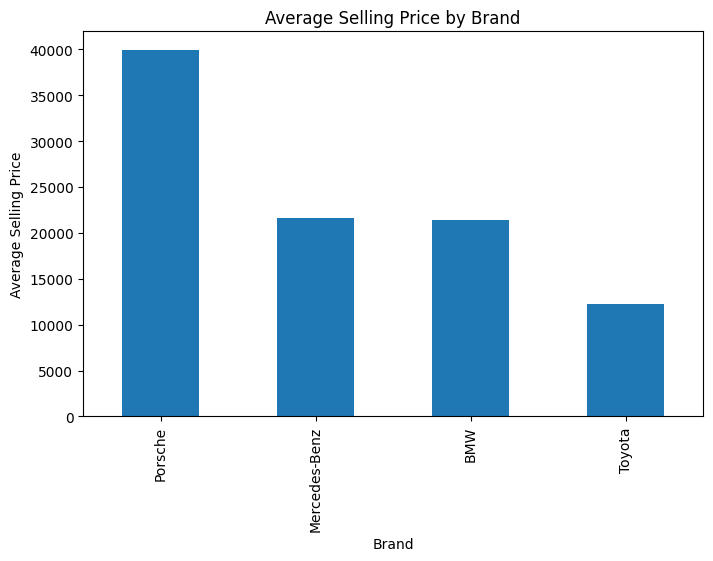

In [21]:
df[df['make'].isin(brands)].groupby('make')['sellingprice'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(8,5))
plt.title('Average Selling Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Selling Price')
plt.show()

Porsche has the highest average selling price among selected brands, significantly exceeding both BMW and Mercedes-Benz. Toyota, representing the mass market segment, shows the lowest average price.

In [13]:
# find out the specifics of the Porsche and the details
porsche = df[df['make']== 'Porsche']
porsche['model'].value_counts().head(10)

,count
model,
Cayenne,562
Panamera,268
Boxster,235
911,229
Cayman,66
Cayman S,15
Macan,8


<Axes: xlabel='odometer', ylabel='sellingprice'>

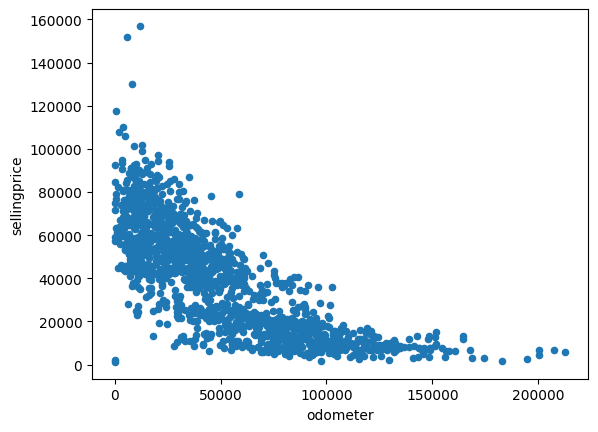

In [14]:
porsche.plot.scatter(x='odometer',y='sellingprice')

There is a clear negative correlation between mileage and selling price for Porsche vehicles: cars with lower mileage tend to have significantly higher prices, while higher mileage vehicles show reduced prices due to depreciation effects.

In [17]:
porsche.groupby('year')['sellingprice'].mean().sort_values(ascending=False)

,sellingprice
year,
2014,66080.207921
2013,64615.953307
2015,60881.250000
2012,54033.203125
2011,46339.230769
2010,35960.000000
2007,27121.428571
2008,25678.773585
2009,24292.727273


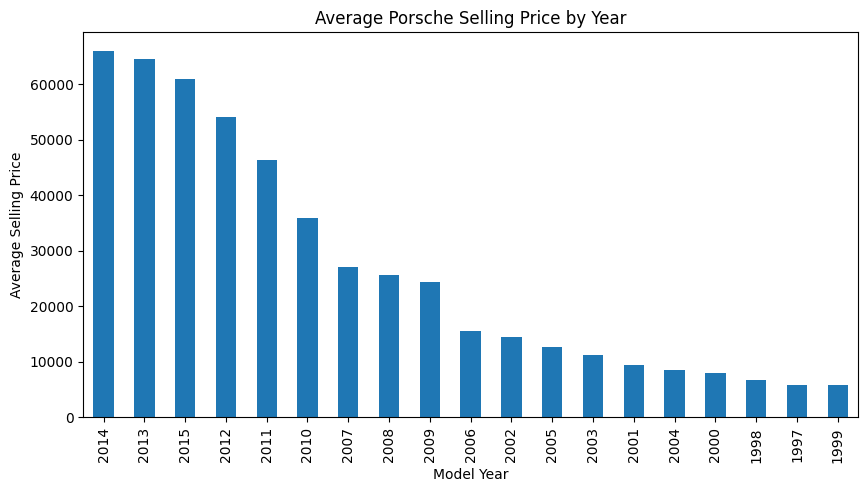

In [15]:
porsche.groupby('year')['sellingprice'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(10,5))
plt.title('Average Porsche Selling Price by Year')
plt.xlabel('Model Year')
plt.ylabel('Average Selling Price')
plt.show()


The analysis shows a strong non-linear depreciation pattern: large price differences exist between older and newer vehicles, while adjacent model years (e.g., 2013 vs 2014) show only minor variations in selling price.

In [19]:
df[['odometer','sellingprice']].corr()

,odometer,sellingprice
odometer,1.000000,-0.582393
sellingprice,-0.582393,1.000000


In [21]:
df[['year','sellingprice']].corr()

,year,sellingprice
year,1.00000,0.58648
sellingprice,0.58648,1.00000


In [22]:
df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)

,sellingprice
make,
Rolls-Royce,153488.235294
Ferrari,127210.526316
Lamborghini,112625.000000
Bentley,74367.672414
airstream,71000.000000
...,...
dodge tk,550.000000
Geo,528.947368
dot,500.000000


The analysis shows that vehicle price is influenced by three main factors:
1. Mileage has a negative correlation with price — higher mileage leads to lower value.
2. Model year has a positive relationship with price — newer cars are significantly more expensive.
3. Brand plays a major role, with luxury brands such as Porsche, Ferrari, and Rolls-Royce having substantially higher average prices compared to mass-market brands like Toyota,Daewoo

Overall, brand positioning appears to be the strongest factor, followed by mileage and manufacturing year.

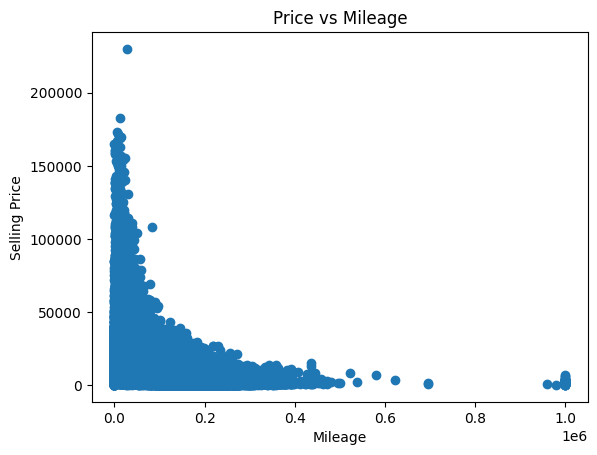

In [10]:
import matplotlib.pyplot as plt
plt.scatter(df['odometer'],df['sellingprice'])
plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.title('Price vs Mileage')
plt.show()

## Conclusion

This analysis explored a used car sales dataset to understand the main factors affecting vehicle pricing.

The results show that brand is one of the strongest pricing factors. Luxury brands such as Porsche, Ferrari, and Rolls-Royce have significantly higher average selling prices compared to mass-market brands like Toyota and Ford.

Mileage also has a clear negative relationship with price. Cars with higher mileage tend to sell for lower prices, which confirms the expected depreciation effect.

Additionally, newer vehicles generally have higher selling prices, indicating that vehicle age plays an important role in determining market value.

Overall, car pricing in this dataset is mainly influenced by brand category, mileage, and manufacturing year.